# Load and Explore Data

In [ ]:
import pandas as pd
import numpy as np

import os
from nltk.stem.porter import PorterStemmer
from tqdm import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# File paths
RAW_CSV_DIR = "data/df.csv"
CLEAN_CSV_DIR = "data/cleaned_df.csv"

# Check if the cleaned data already exists
if os.path.exists(CLEAN_CSV_DIR):
    print(f"Found existing cleaned dataset at {CLEAN_CSV_DIR}. Loading instantly...")
    df = pd.read_csv(CLEAN_CSV_DIR)
    
else:
    print(f"Cleaned dataset not found. Loading raw data from {RAW_CSV_DIR}...")
    df = pd.read_csv(RAW_CSV_DIR)
    df = df.dropna(subset=['text'])
    
    # stemmer and progress bar
    ps = PorterStemmer()
    tqdm.pandas()
    
    def clean_spam_text(text):
        if not isinstance(text, str):
            return ""
        return ' '.join([ps.stem(word) for word in text.split()])

    # it takes some time to stem all the df
    df['cleaned_text'] = df['text'].progress_apply(clean_spam_text)
    
    # save it so this never has to run again
    df.to_csv(CLEAN_CSV_DIR, index=False)
    print("Saved successfully!")

df = df.dropna(subset=['cleaned_text', 'label'])
# filter out purely empty strings
df = df[df['cleaned_text'].str.strip() != '']

X = df['cleaned_text']
y = df['label'] # 0 -> ham, 1 -> phish, 2 -> spam

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# only words:
# - atleast in two documents to prevent overfitting
# - not in more than 70% of the documents, reduce "corpus-specific" words
# let CountVectorizer handle lowercasing and stop words
text_clf = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=2, max_df=0.7)), 
    ('clf', MultinomialNB())
])

text_clf.fit(X_train, y_train)

predictions = text_clf.predict(X_test)

print(classification_report(y_test, predictions))

Found existing cleaned dataset at data/cleaned_df.csv. Loading instantly...
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     33709
           1       0.74      0.84      0.79      8626
           2       0.94      0.86      0.90     30754

    accuracy                           0.92     73089
   macro avg       0.87      0.90      0.88     73089
weighted avg       0.92      0.92      0.92     73089



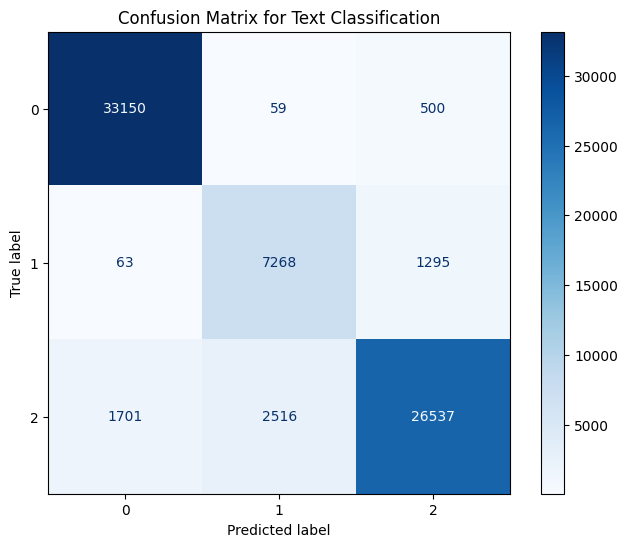

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

_, ax = plt.subplots(figsize=(8, 6))

# Use from_estimator to predict and plot in one go
cmd = ConfusionMatrixDisplay.from_estimator(
    text_clf, 
    X_test, 
    y_test, 
    display_labels=text_clf.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix for Text Classification')
plt.show()